In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import ResNet50

from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


E0000 00:00:1778770651.228849      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778770651.289645      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778770651.778476      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778770651.778525      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778770651.778528      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778770651.778531      57 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
dataset_path = "/kaggle/input/datasets/mahekmehra/cv-project"

print(os.listdir(dataset_path))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [4]:
yaml_content = f"""

train: {dataset_path}/train/images
val: {dataset_path}/valid/images
test: {dataset_path}/test/images

nc: 4

names:
  0: Flowering
  1: Germination
  2: Harvesting
  3: Vegetative
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("YAML Fixed")

YAML Fixed


In [6]:
model = YOLO("yolov8n.pt")

In [7]:
results = model.train(












    
    data="/kaggle/working/data.yaml",

    epochs=20,

    imgsz=640,

    batch=16
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [8]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 36.0±12.0 MB/s, size: 47.2 KB)
val: Scanning /kaggle/input/datasets/mahekmehra/cv-project/valid/labels... 1462 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1462/1462 424.8it/s 3.4s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mahekmehra/cv-project/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 7.4it/s 12.4s0.1s
                   all       1462       1743      0.972      0.964      0.985      0.724
             Flowering        366        408      0.984      0.973      0.992      0.787
           Germination        365        365      0.985      0.981      0.978      0.628
            Harvesting        365        601      0.925      0.909      0.976 

In [9]:
results = model.predict(

    source=f"{dataset_path}/test/images",

    save=True
)


image 1/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w10_90_006207_JPG.rf.17813cf045d1047dcd86c507f53d36a3.jpg: 640x640 1 Harvesting, 7.9ms
image 2/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w10_90_006209_JPG.rf.5c2180661332d891acfa734c1b7535d6.jpg: 640x640 2 Harvestings, 7.3ms
image 3/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w11_90_006220_JPG.rf.72641de9a269e43dfef1a58adf37b668.jpg: 640x640 1 Harvesting, 7.2ms
image 4/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w11_90_006224_JPG.rf.1fcee3b045f4df8bd2c1ee1a85ad648d.jpg: 640x640 1 Harvesting, 7.2ms
image 5/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w1_90_000970_JPG.rf.ceb84139f1b44c0368c33bad974e008e.jpg: 640x640 1 Germination, 7.2ms
image 6/730 /kaggle/input/datasets/mahekmehra/cv-project/test/images/aug_0_crop_bean_w1_90_000978_JPG.rf.85f1303b152fc0a867ff1c4597dd3def.

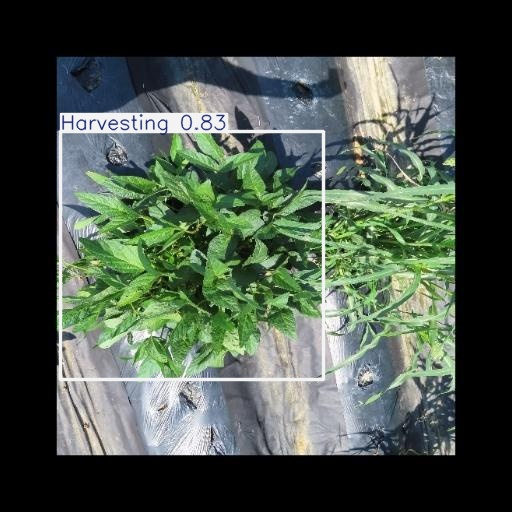

In [10]:
from IPython.display import Image

Image(
    filename="/kaggle/working/runs/detect/predict/aug_0_crop_bean_w10_90_006207_JPG.rf.17813cf045d1047dcd86c507f53d36a3.jpg"
)

In [21]:
print(

    os.listdir(
        "/kaggle/working/classification_dataset"
    )
)

['Vegetative', 'Flowering', 'Harvesting', 'Germination']


In [8]:
import tensorflow as tf

import matplotlib.pyplot as plt

import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import ResNet50

from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

In [22]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.7,1.3]
)

In [23]:
train_data = train_datagen.flow_from_directory(

    "/kaggle/working/classification_dataset",

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)


val_data = train_datagen.flow_from_directory(

    "/kaggle/working/classification_dataset",

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation'
)

Found 12275 images belonging to 4 classes.
Found 3067 images belonging to 4 classes.


In [24]:
base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
resnet_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        4,
        activation='softmax'
    )
])

In [22]:
resnet_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [23]:
history = resnet_model.fit(

    train_data,

    validation_data=val_data,

    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1778520575.811216     247 service.cc:152] XLA service 0x7fcaa4018280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778520575.811259     247 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778520575.811263     247 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778520577.766259     247 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/384 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.2812 - loss: 1.6083   

I0000 00:00:1778520582.390644     247 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


384/384 ━━━━━━━━━━━━━━━━━━━━ 236s 581ms/step - accuracy: 0.3413 - loss: 1.3305 - val_accuracy: 0.4653 - val_loss: 1.2411
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 208s 541ms/step - accuracy: 0.4096 - loss: 1.2460 - val_accuracy: 0.4855 - val_loss: 1.1708
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 209s 544ms/step - accuracy: 0.4593 - loss: 1.1807 - val_accuracy: 0.4940 - val_loss: 1.1214
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 207s 539ms/step - accuracy: 0.4993 - loss: 1.1427 - val_accuracy: 0.5276 - val_loss: 1.0912
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 208s 541ms/step - accuracy: 0.5091 - loss: 1.1131 - val_accuracy: 0.5152 - val_loss: 1.0967
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 209s 545ms/step - accuracy: 0.5163 - loss: 1.0944 - val_accuracy: 0.5461 - val_loss: 1.0679
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 207s 538ms/step - accuracy: 0.5235 - loss: 1.0767 - val_accuracy: 0.5510 - val_loss: 1.0470
Epoch 8/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 204s 530ms/step - accuracy: 0.5262 - loss: 1.07

In [24]:
loss, accuracy = resnet_model.evaluate(val_data)

print("ResNet Accuracy:", accuracy)

96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 432ms/step - accuracy: 0.5434 - loss: 1.0425
ResNet Accuracy: 0.5598304271697998


In [14]:
cnn_model = models.Sequential([

    layers.Conv2D(

        32,

        (3,3),

        activation='relu',

        input_shape=(224,224,3)
    ),

    layers.MaxPooling2D(2,2),


    layers.Conv2D(

        64,

        (3,3),

        activation='relu'
    ),

    layers.MaxPooling2D(2,2),


    layers.Conv2D(

        128,

        (3,3),

        activation='relu'
    ),

    layers.MaxPooling2D(2,2),


    layers.Flatten(),


    layers.Dense(

        128,

        activation='relu'
    ),

    layers.Dropout(0.3),


    layers.Dense(

        4,

        activation='softmax'
    )
])

In [15]:
cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [16]:
cnn_history = cnn_model.fit(

    train_data,

    validation_data=val_data,

    epochs=20
)

Epoch 1/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 196s 502ms/step - accuracy: 0.5437 - loss: 1.0460 - val_accuracy: 0.6964 - val_loss: 0.6922
Epoch 2/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 192s 500ms/step - accuracy: 0.7561 - loss: 0.6048 - val_accuracy: 0.7502 - val_loss: 0.5982
Epoch 3/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 192s 501ms/step - accuracy: 0.7826 - loss: 0.5436 - val_accuracy: 0.7926 - val_loss: 0.5270
Epoch 4/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 193s 501ms/step - accuracy: 0.8101 - loss: 0.4688 - val_accuracy: 0.8259 - val_loss: 0.4443
Epoch 5/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 191s 496ms/step - accuracy: 0.8328 - loss: 0.4224 - val_accuracy: 0.8233 - val_loss: 0.4575
Epoch 6/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 192s 500ms/step - accuracy: 0.8440 - loss: 0.3965 - val_accuracy: 0.8516 - val_loss: 0.3621
Epoch 7/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 190s 494ms/step - accuracy: 0.8639 - loss: 0.3398 - val_accuracy: 0.8471 - val_loss: 0.3669
Epoch 8/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 188s 491ms/step - accuracy: 0.8665 -

In [17]:
loss, accuracy = cnn_model.evaluate(val_data)

print("CNN Accuracy:", accuracy)

96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.9004 - loss: 0.2470
CNN Accuracy: 0.9064232110977173


In [18]:
cnn_model.save(

    "/kaggle/working/cnn_model.keras"
)

In [19]:
import matplotlib.pyplot as plt

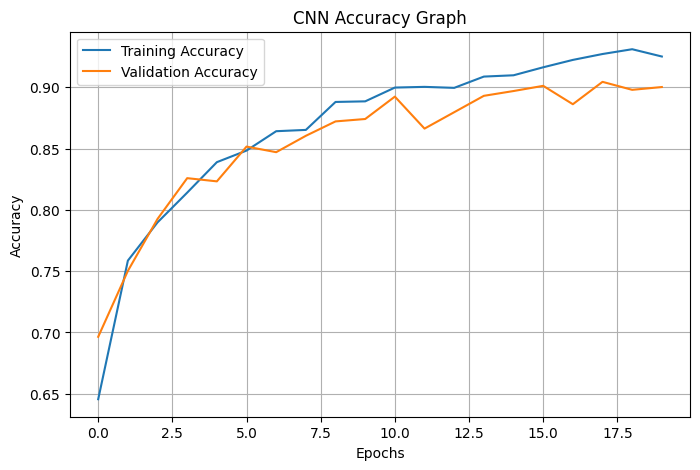

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy Graph")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

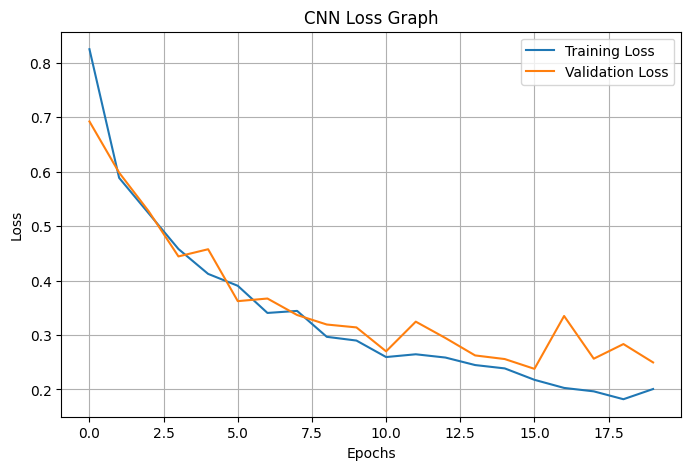

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

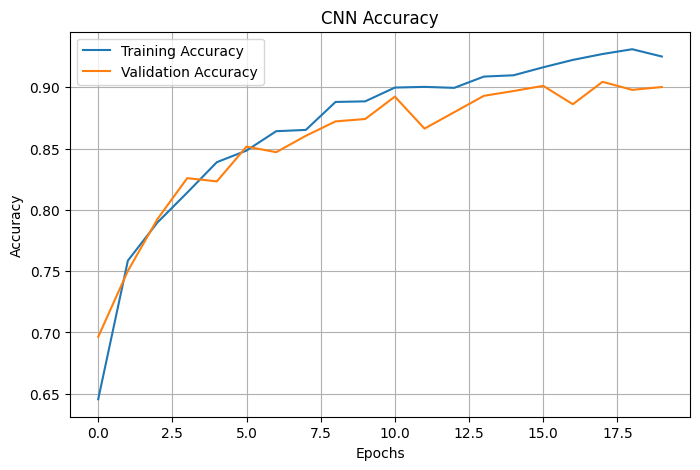

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.savefig(
    "/kaggle/working/cnn_accuracy.png"
)

plt.show()

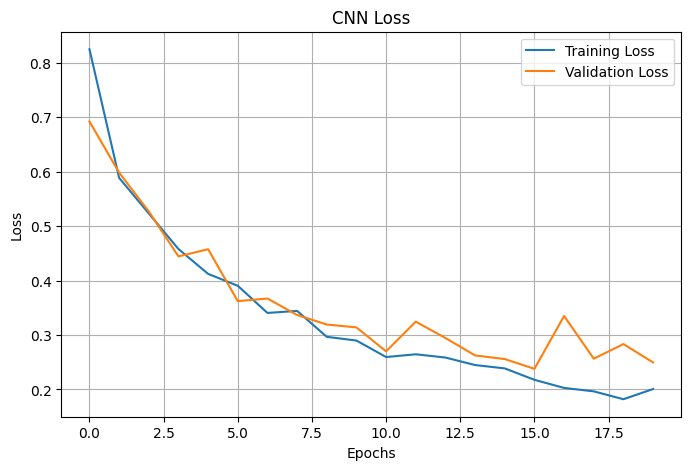

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.savefig(
    "/kaggle/working/cnn_loss.png"
)

plt.show()

In [24]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import numpy as np

In [25]:
predictions = cnn_model.predict(val_data)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = val_data.classes

96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 385ms/step


In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[212 182 160 214]
 [210 187 175 194]
 [218 189 161 197]
 [212 203 162 191]]


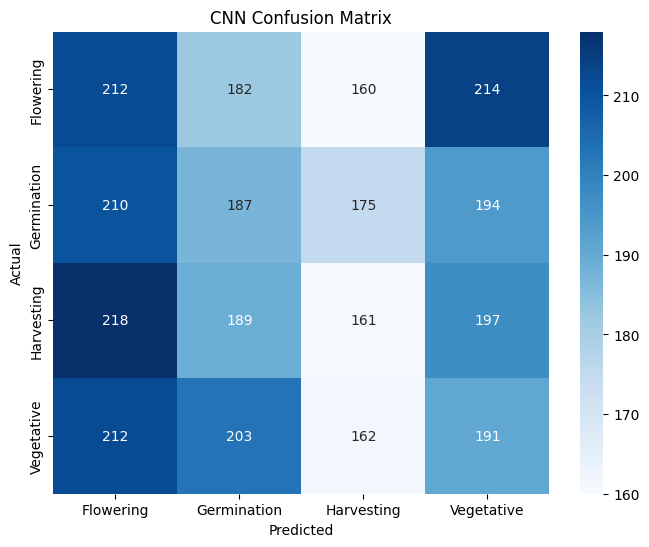

In [27]:
class_names = [

    "Flowering",

    "Germination",

    "Harvesting",

    "Vegetative"
]


plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "/kaggle/working/cnn_confusion_matrix.png"
)

plt.show()

In [28]:
from sklearn.metrics import classification_report

In [29]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names
    )
)

              precision    recall  f1-score   support

   Flowering       0.25      0.28      0.26       768
 Germination       0.25      0.24      0.24       766
  Harvesting       0.24      0.21      0.23       765
  Vegetative       0.24      0.25      0.24       768

    accuracy                           0.24      3067
   macro avg       0.24      0.24      0.24      3067
weighted avg       0.24      0.24      0.24      3067



In [30]:
import random

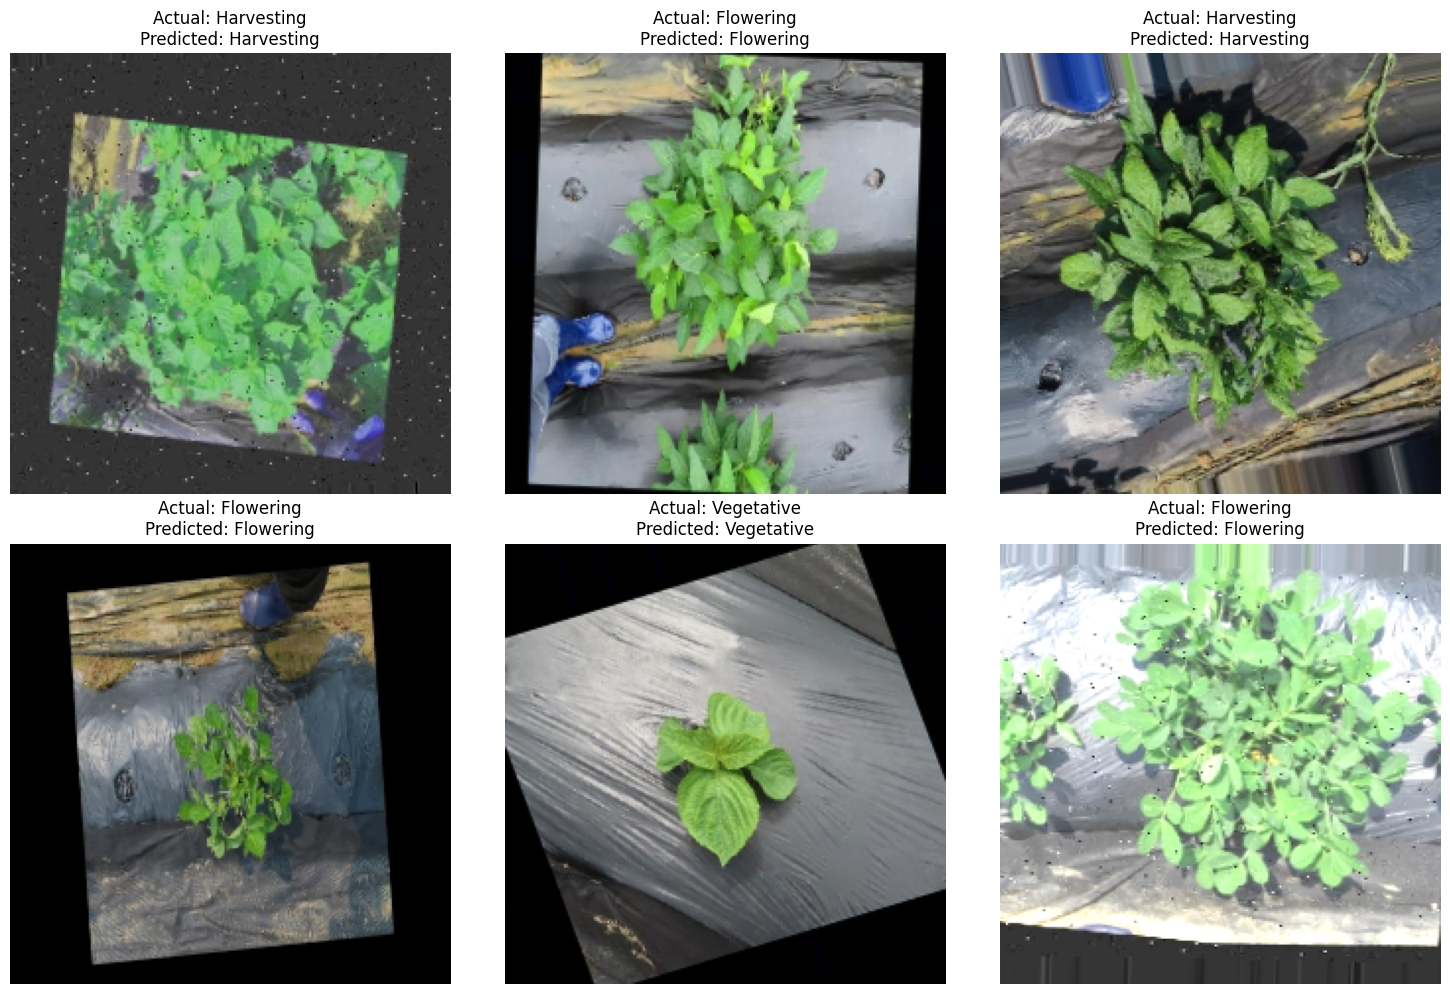

In [31]:
images, labels = next(val_data)

class_labels = class_names


plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = images[i]

    actual = class_labels[
        np.argmax(labels[i])
    ]

    pred = class_labels[
        np.argmax(
            cnn_model.predict(
                np.expand_dims(img, axis=0),
                verbose=0
            )
        )
    ]

    plt.imshow(img)

    plt.title(
        f"Actual: {actual}\nPredicted: {pred}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    "/kaggle/working/cnn_predictions.png"
)

plt.show()

In [32]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,430 (127.82 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,954 (85.22 MB)

In [33]:
import os

dataset = "/kaggle/working/classification_dataset"

for folder in os.listdir(dataset):

    path = os.path.join(dataset, folder)

    print(folder, len(os.listdir(path)))

Vegetative 3843
Flowering 3840
Harvesting 3828
Germination 3831


In [34]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),


    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),


    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),


    layers.Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),


    layers.Flatten(),


    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),


    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),


    layers.Dense(
        4,
        activation='softmax'
    )
])

In [35]:
cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [28]:
cnn_history = cnn_model.fit(

    train_data,

    validation_data=val_data,

    epochs=20
)

ValueError: You must call `compile()` before using the model.

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [40]:
cnn_history = cnn_model.fit(

    train_data,

    validation_data=val_data,

    epochs=20,

    callbacks=[early_stop]
)

Epoch 1/20
273/384 ━━━━━━━━━━━━━━━━━━━━ 44s 404ms/step - accuracy: 0.4690 - loss: 4.9605

KeyboardInterrupt: 

In [5]:
import os
import shutil

# =========================
# PATHS
# =========================

dataset_path = "/kaggle/input/datasets/mahekmehra/cv-project"

output_path = "/kaggle/working/classification_dataset"

# =========================
# CLASS NAMES
# =========================

classes = [

    "Flowering",

    "Germination",

    "Harvesting",

    "Vegetative"
]

# =========================
# CREATE FOLDERS
# =========================

for split in ["train", "valid", "test"]:

    for cls in classes:

        os.makedirs(
            f"{output_path}/{split}/{cls}",
            exist_ok=True
        )

# =========================
# CONVERT YOLO TO CNN FORMAT
# =========================

for split in ["train", "valid", "test"]:

    image_folder = f"{dataset_path}/{split}/images"

    label_folder = f"{dataset_path}/{split}/labels"

    for label_file in os.listdir(label_folder):

        if label_file.endswith(".txt"):

            label_path = os.path.join(
                label_folder,
                label_file
            )

            with open(label_path, "r") as f:

                lines = f.readlines()

            if len(lines) > 0:

                class_id = int(
                    lines[0].split()[0]
                )

                class_name = classes[class_id]

                image_name = label_file.replace(
                    ".txt",
                    ".jpg"
                )

                src_image = os.path.join(
                    image_folder,
                    image_name
                )

                dst_image = os.path.join(
                    output_path,
                    split,
                    class_name,
                    image_name
                )

                if os.path.exists(src_image):

                    shutil.copy(
                        src_image,
                        dst_image
                    )

print("Dataset converted successfully!")

Dataset converted successfully!


In [8]:
# =========================
# KAGGLE CUSTOM CNN TRAINING
# =========================

import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================
# CHECK GPU
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# =========================
# DATASET PATH
# =========================

# CHANGE THIS TO YOUR KAGGLE DATASET NAME

dataset_path = "/kaggle/working/classification_dataset"

print(os.listdir(dataset_path))

# =========================
# IMAGE TRANSFORMATIONS
# =========================

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3
    ),

    transforms.GaussianBlur(
        kernel_size=3
    ),

    transforms.ToTensor()
])

# =========================
# LOAD DATASET
# =========================

train_dataset = datasets.ImageFolder(

    root=f"{dataset_path}/train",

    transform=transform
)

valid_dataset = datasets.ImageFolder(

    root=f"{dataset_path}/valid",

    transform=transform
)

# =========================
# DATALOADERS
# =========================

train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True
)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=16,

    shuffle=False
)

# =========================
# CLASS NAMES
# =========================

classes = train_dataset.classes

print("Classes:", classes)

# =========================
# CUSTOM CNN MODEL
# =========================

class CropCNN(nn.Module):

    def __init__(self):

        super(CropCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            3,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(
            128 * 28 * 28,
            256
        )

        self.fc2 = nn.Linear(
            256,
            4
        )

    def forward(self, x):

        x = self.pool(
            self.relu(self.conv1(x))
        )

        x = self.pool(
            self.relu(self.conv2(x))
        )

        x = self.pool(
            self.relu(self.conv3(x))
        )

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x

# =========================
# LOAD MODEL
# =========================

model = CropCNN().to(device)

# =========================
# LOSS & OPTIMIZER
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

# =========================
# TRAINING
# =========================

epochs = 10

train_accuracies = []
valid_accuracies = []

for epoch in range(epochs):

    # =========================
    # TRAINING MODE
    # =========================

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_accuracy = 100 * correct / total

    train_accuracies.append(train_accuracy)

    # =========================
    # VALIDATION MODE
    # =========================

    model.eval()

    valid_correct = 0

    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            valid_total += labels.size(0)

            valid_correct += (
                predicted == labels
            ).sum().item()

    valid_accuracy = (
        100 * valid_correct / valid_total
    )

    valid_accuracies.append(valid_accuracy)

    # =========================
    # PRINT RESULTS
    # =========================

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Training Loss: {running_loss:.4f}")

    print(f"Training Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Accuracy: {valid_accuracy:.2f}%")

# =========================
# SAVE MODEL
# =========================

torch.save(

    model.state_dict(),

    "/kaggle/working/crop_cnn_model.pth"
)

print("\nModel saved successfully!")

# =========================
# SHOW OUTPUT FILES
# =========================

print("\nFiles in /kaggle/working:")

print(os.listdir("/kaggle/working"))

Using Device: cuda
['valid', 'test', 'train', 'Harvesting', 'Flowering', 'Vegetative', 'Germination']
Classes: ['Flowering', 'Germination', 'Harvesting', 'Vegetative']

Epoch [1/10]
Training Loss: 1331.8437
Training Accuracy: 24.41%
Validation Accuracy: 25.03%

Epoch [2/10]
Training Loss: 1329.6039
Training Accuracy: 24.85%
Validation Accuracy: 25.03%

Epoch [3/10]
Training Loss: 1331.3850
Training Accuracy: 24.46%
Validation Accuracy: 25.03%

Epoch [4/10]
Training Loss: 1137.9818
Training Accuracy: 41.35%
Validation Accuracy: 69.63%

Epoch [5/10]
Training Loss: 695.7168
Training Accuracy: 69.38%
Validation Accuracy: 74.49%

Epoch [6/10]
Training Loss: 601.2706
Training Accuracy: 74.74%
Validation Accuracy: 79.27%

Epoch [7/10]
Training Loss: 554.0973
Training Accuracy: 77.06%
Validation Accuracy: 83.17%

Epoch [8/10]
Training Loss: 528.6333
Training Accuracy: 77.79%
Validation Accuracy: 84.68%

Epoch [9/10]
Training Loss: 495.7822
Training Accuracy: 78.84%
Validation Accuracy: 85.23%


In [6]:
# =========================
# KAGGLE RESNET50 TRAINING
# =========================

import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

# =========================
# DEVICE
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# =========================
# DATASET PATH
# =========================

dataset_path = "/kaggle/working/classification_dataset"

print(os.listdir(dataset_path))

# =========================
# IMAGE TRANSFORMS
# =========================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3
    ),

    transforms.GaussianBlur(
        kernel_size=3
    ),

    transforms.ToTensor()
])

# =========================
# LOAD DATASETS
# =========================

train_dataset = datasets.ImageFolder(

    root=f"{dataset_path}/train",

    transform=transform
)

valid_dataset = datasets.ImageFolder(

    root=f"{dataset_path}/valid",

    transform=transform
)

# =========================
# DATALOADERS
# =========================

train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True
)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=16,

    shuffle=False
)

# =========================
# CLASS NAMES
# =========================

classes = train_dataset.classes

print("Classes:", classes)

# =========================
# LOAD RESNET50
# =========================

model = models.resnet50(
    pretrained=True
)

# =========================
# FREEZE LAYERS
# =========================

for param in model.parameters():

    param.requires_grad = False

# =========================
# MODIFY FINAL LAYER
# =========================

num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(
        num_features,
        256
    ),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(
        256,
        4
    )
)

model = model.to(device)

# =========================
# LOSS FUNCTION
# =========================

criterion = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# =========================

optimizer = optim.Adam(

    model.fc.parameters(),

    lr=0.001
)

# =========================
# TRAINING
# =========================

epochs = 10

train_accuracies = []

valid_accuracies = []

for epoch in range(epochs):

    # =========================
    # TRAIN MODE
    # =========================

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_accuracy = 100 * correct / total

    train_accuracies.append(
        train_accuracy
    )

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    valid_correct = 0

    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            valid_total += labels.size(0)

            valid_correct += (
                predicted == labels
            ).sum().item()

    valid_accuracy = (
        100 * valid_correct / valid_total
    )

    valid_accuracies.append(
        valid_accuracy
    )

    # =========================
    # PRINT RESULTS
    # =========================

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Training Loss: {running_loss:.4f}")

    print(f"Training Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Accuracy: {valid_accuracy:.2f}%")

# =========================
# SAVE MODEL
# =========================

torch.save(

    model.state_dict(),

    "/kaggle/working/resnet_model.pth"
)

print("\nResNet50 model saved successfully!")

# =========================
# SHOW FILES
# =========================

print("\nFiles in /kaggle/working:")

print(os.listdir("/kaggle/working"))

Using Device: cuda
['test', 'valid', 'train']
Classes: ['Flowering', 'Germination', 'Harvesting', 'Vegetative']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]



Epoch [1/10]
Training Loss: 629.0627
Training Accuracy: 73.28%
Validation Accuracy: 86.80%

Epoch [2/10]
Training Loss: 505.1975
Training Accuracy: 78.73%
Validation Accuracy: 88.65%

Epoch [3/10]
Training Loss: 491.0955
Training Accuracy: 79.47%
Validation Accuracy: 87.55%

Epoch [4/10]
Training Loss: 466.1446
Training Accuracy: 80.73%
Validation Accuracy: 87.89%

Epoch [5/10]
Training Loss: 453.2159
Training Accuracy: 81.07%
Validation Accuracy: 88.51%

Epoch [6/10]
Training Loss: 440.2285
Training Accuracy: 81.34%
Validation Accuracy: 89.12%

Epoch [7/10]
Training Loss: 444.8734
Training Accuracy: 81.51%
Validation Accuracy: 88.37%

Epoch [8/10]
Training Loss: 429.0250
Training Accuracy: 81.88%
Validation Accuracy: 90.42%

Epoch [9/10]
Training Loss: 424.4298
Training Accuracy: 82.20%
Validation Accuracy: 88.85%

Epoch [10/10]
Training Loss: 403.4983
Training Accuracy: 82.88%
Validation Accuracy: 88.92%

ResNet50 model saved successfully!

Files in /kaggle/working:
['data.yaml', '.

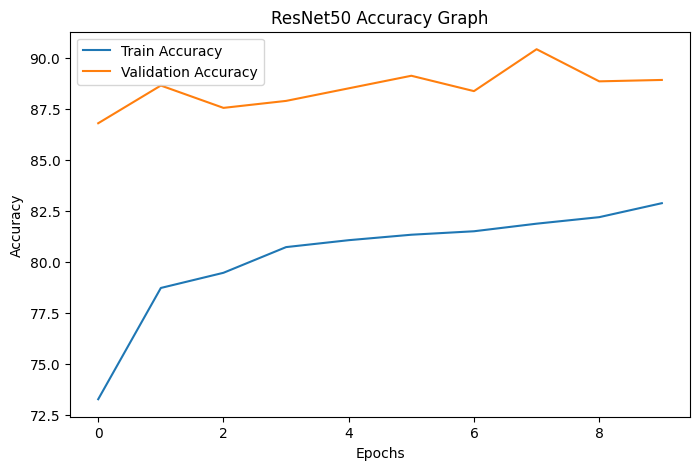

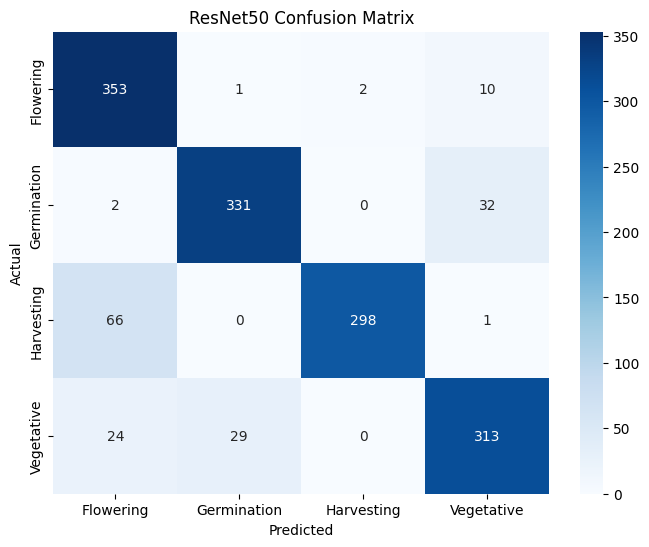


Classification Report:

              precision    recall  f1-score   support

   Flowering       0.79      0.96      0.87       366
 Germination       0.92      0.91      0.91       365
  Harvesting       0.99      0.82      0.90       365
  Vegetative       0.88      0.86      0.87       366

    accuracy                           0.89      1462
   macro avg       0.90      0.89      0.89      1462
weighted avg       0.90      0.89      0.89      1462



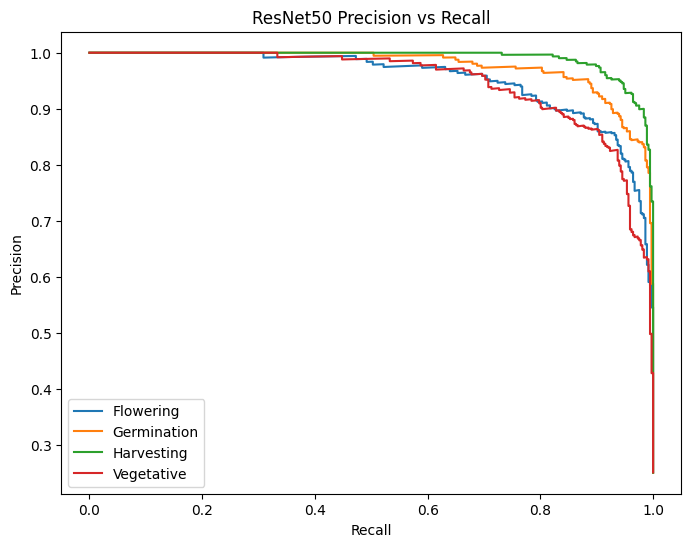

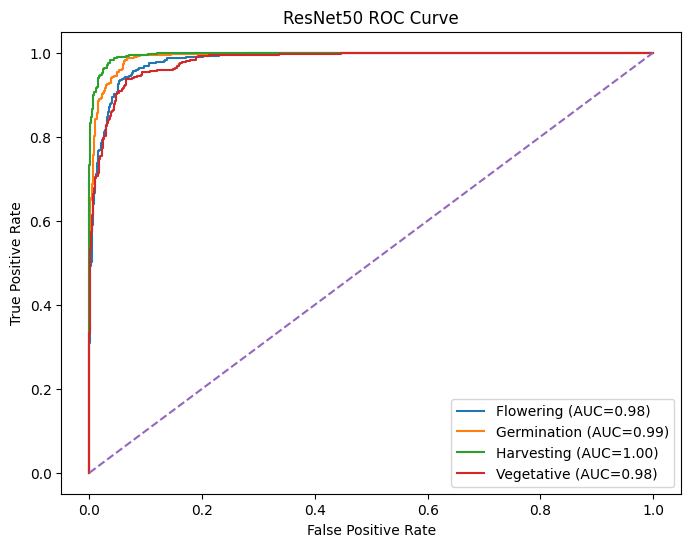


Generated Files:

['resnet_accuracy.jpeg', 'data.yaml', 'resnet_precision_recall.jpeg', '.virtual_documents', 'resnet_confusion_matrix.jpeg', 'classification_dataset', 'resnet_model.pth', 'resnet_roc_curve.jpeg']


In [7]:
# =========================
# RESNET50 EVALUATION CODE
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import seaborn as sns

# =========================
# EVALUATION MODE
# =========================

model.eval()

all_labels = []

all_predictions = []

all_probabilities = []

# =========================
# PREDICTIONS
# =========================

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

# =========================
# CONVERT TO NUMPY
# =========================

all_labels = np.array(all_labels)

all_predictions = np.array(all_predictions)

all_probabilities = np.array(all_probabilities)

# =========================
# ACCURACY GRAPH
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    valid_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("ResNet50 Accuracy Graph")

plt.legend()

plt.savefig(
    "/kaggle/working/resnet_accuracy.jpeg"
)

plt.show()

# =========================
# LOSS GRAPH
# =========================

# OPTIONAL PLACEHOLDER
# If you saved losses during training

# Example:
# train_losses.append(loss.item())

# Uncomment if available

"""
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("ResNet50 Loss Graph")

plt.legend()

plt.savefig(
    "/kaggle/working/resnet_loss.jpeg"
)

plt.show()
"""

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ResNet50 Confusion Matrix")

plt.savefig(
    "/kaggle/working/resnet_confusion_matrix.jpeg"
)

plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=classes
    )
)

# =========================
# PRECISION RECALL CURVE
# =========================

labels_bin = label_binarize(
    all_labels,
    classes=[0,1,2,3]
)

plt.figure(figsize=(8,6))

for i in range(4):

    precision, recall, _ = precision_recall_curve(

        labels_bin[:, i],

        all_probabilities[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=classes[i]
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("ResNet50 Precision vs Recall")

plt.legend()

plt.savefig(
    "/kaggle/working/resnet_precision_recall.jpeg"
)

plt.show()

# =========================
# ROC CURVE
# =========================

plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(

        labels_bin[:, i],

        all_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(

        fpr,

        tpr,

        label=f"{classes[i]} (AUC={roc_auc:.2f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ResNet50 ROC Curve")

plt.legend()

plt.savefig(
    "/kaggle/working/resnet_roc_curve.jpeg"
)

plt.show()

# =========================
# SHOW GENERATED FILES
# =========================

import os

print("\nGenerated Files:\n")

print(os.listdir("/kaggle/working"))